# Gaussian Discriminant Analysis (GDA) for Painting Classification

This notebook implements a complete GDA pipeline to predict which of three paintings
(`The Persistence of Memory`, `The Starry Night`, `The Water Lily Pond`) a survey response
describes. We compare LDA (shared covariance) and QDA (per-class covariance), tune
regularization via group-based cross-validation, and export a lightweight `pred.py`
that uses only `numpy` and `pandas`.

## Step 1. Imports and constants

We keep all tunable constants in one place for reproducibility. Key design choices:
- **Random seed**: `42` for deterministic splits
- **Data split**: 70 % train / 10 % validation / 20 % test, split by `unique_id` to prevent data leakage
- **TF-IDF vocabulary**: top 200 words by document frequency, with `min_df=3`
- **Regularization search**: `λ ∈ {0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0}`

In [1]:
import json
import re
import warnings
from pathlib import Path
from collections import Counter
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── paths ──
CSV_PATH = "training_data_202601.csv"
OUTPUT_DIR = Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── column renaming ──
COLUMN_MAP = {
    "Painting": "painting",
    "On a scale of 1\u201310, how intense is the emotion conveyed by the artwork?": "emotion_rating",
    "Describe how this painting makes you feel.": "feel_describe",
    "This art piece makes me feel sombre.": "sombre",
    "This art piece makes me feel content.": "content",
    "This art piece makes me feel calm.": "calm",
    "This art piece makes me feel uneasy.": "uneasy",
    "How many prominent colours do you notice in this painting?": "colors",
    "How many objects caught your eye in the painting?": "objects",
    "How much (in Canadian dollars) would you be willing to pay for this painting?": "price",
    "If you could purchase this painting, which room would you put that painting in?": "room",
    "If you could view this art in person, who would you want to view it with?": "exhibition_with",
    "What season does this art piece remind you of?": "season",
    "If this painting was a food, what would be?": "food",
    "Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.": "soundtrack",
}

# ── feature groups ──
LIKERT_COLS = ["sombre", "content", "calm", "uneasy"]
NUMERIC_COLS = ["emotion_rating", "sombre", "content", "calm", "uneasy", "colors", "objects", "log_price"]
SEASON_CATS = ["Spring", "Summer", "Fall", "Winter"]
ROOM_CATS = ["Bedroom", "Bathroom", "Office", "Living room", "Dining room"]
COMP_CATS = ["Friends", "Family members", "By yourself", "Coworkers/Classmates", "Strangers"]
TEXT_COLS = ["feel_describe", "food", "soundtrack"]
BINARY_COLS = (
    [f"season_{c}" for c in SEASON_CATS]
    + [f"room_{c}" for c in ROOM_CATS]
    + [f"comp_{c}" for c in COMP_CATS]
)
CLASS_NAMES = ["The Persistence of Memory", "The Starry Night", "The Water Lily Pond"]
K = len(CLASS_NAMES)

# ── hyperparameter search space ──
REG_LAMBDAS = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
MAX_FEATURES_LIST = [100, 200, 300]
N_CV_SPLITS = 5
SEED = 42

print("Constants loaded.")
print(f"Classes: {CLASS_NAMES}")
print(f"Regularization search: {REG_LAMBDAS}")
print(f"TF-IDF vocab sizes:   {MAX_FEATURES_LIST}")

Constants loaded.
Classes: ['The Persistence of Memory', 'The Starry Night', 'The Water Lily Pond']
Regularization search: [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
TF-IDF vocab sizes:   [100, 200, 300]


## Step 2. Data loading and parsing utilities

The raw survey data contains several messy fields that need careful parsing:

| Field type | Example raw value | Parsed value |
|---|---|---|
| Likert scale | `"4 - Agree"` | `4.0` |
| Price (text) | `"300 dollars."`, `"$5"`, `"5 000 000$"` | `300.0`, `5.0`, `5000000.0` |
| Multi-label | `"Bedroom,Bathroom"` | binary columns `[1, 1, 0, 0, 0]` |

We also apply `log1p` to the cleaned price to reduce right-skew, and cap values above 1 billion as implausible.

In [2]:
def extract_likert(value) -> float:
    """Parse Likert string '4 - Agree' -> 4.0."""
    if pd.isna(value):
        return np.nan
    m = re.match(r"^(\d+)", str(value).strip())
    return float(m.group(1)) if m else np.nan


def parse_price(value) -> float:
    """Extract a numeric CAD amount from free-text price responses."""
    if pd.isna(value):
        return np.nan
    s = str(value).lower().strip().replace(",", "")
    # range -> midpoint
    m = re.search(r"(\d+\.?\d*)\s*(?:-|\u2013|to)\s*(\d+\.?\d*)", s)
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2
    # multiplier suffixes
    for pat, mult in [
        (r"(\d+\.?\d*)\s*(?:billion|bn|b)\b", 1e9),
        (r"(\d+\.?\d*)\s*(?:million|m)\b", 1e6),
        (r"(\d+\.?\d*)\s*k\b", 1e3),
    ]:
        m = re.search(pat, s)
        if m:
            return float(m.group(1)) * mult
    # first bare number
    m = re.search(r"(\d+\.?\d*)", s)
    if m:
        return float(m.group(1))
    return np.nan


def binarize_multi_label(series: pd.Series, categories: list) -> pd.DataFrame:
    """Convert comma-separated multi-label column into binary indicator columns."""
    result = pd.DataFrame(0, index=series.index, columns=categories)
    for idx, val in series.items():
        if pd.notna(val):
            for cat in categories:
                if cat in str(val):
                    result.at[idx, cat] = 1
    return result


def preprocess_raw(df: pd.DataFrame) -> pd.DataFrame:
    """Apply all parsing transformations to the raw dataframe."""
    df = df.copy()
    for col in LIKERT_COLS:
        df[col] = df[col].apply(extract_likert)
    df["price_clean"] = df["price"].apply(parse_price)
    df.loc[df["price_clean"] > 1e9, "price_clean"] = np.nan
    df["log_price"] = np.log1p(df["price_clean"].clip(lower=0))
    for prefix, col, cats in [
        ("season_", "season", SEASON_CATS),
        ("room_", "room", ROOM_CATS),
        ("comp_", "exhibition_with", COMP_CATS),
    ]:
        bindf = binarize_multi_label(df[col], cats)
        for c in cats:
            df[f"{prefix}{c}"] = bindf[c].values
    return df


# quick demo
print("Likert: '4 - Agree'  ->", extract_likert("4 - Agree"))
print("Price:  '$5,000'     ->", parse_price("$5,000"))
print("Price:  '300 dollars' ->", parse_price("300 dollars"))

Likert: '4 - Agree'  -> 4.0
Price:  '$5,000'     -> 5000.0
Price:  '300 dollars' -> 300.0


## Step 3. TF-IDF implementation from scratch

Since `pred.py` cannot import `sklearn`, we implement TF-IDF manually.

Design choices:
- **Tokenization**: lowercase, remove non-alphanumeric, drop tokens with length ≤ 1
- **Term frequency**: sub-linear `1 + log(count)` to dampen high-frequency words
- **Inverse document frequency**: smooth IDF `log((1+N)/(1+df)) + 1` (sklearn convention)
- **Normalization**: L2-normalize each document vector
- **Vocabulary selection**: top `max_features` words by document frequency, with `min_df ≥ 3`

The three text columns (`feel_describe`, `food`, `soundtrack`) are concatenated into a single document per row before vectorization.

In [3]:
def tokenize(text: str) -> list[str]:
    """Lowercase, strip punctuation, split on whitespace, drop short tokens."""
    if not isinstance(text, str) or pd.isna(text):
        return []
    text = re.sub(r"[^a-z0-9\s]", " ", text.lower())
    return [t for t in text.split() if len(t) > 1]


def build_vocabulary(corpus: list[str], max_features: int = 200, min_df: int = 3) -> list[str]:
    """Select top-frequency words that appear in >= min_df documents."""
    doc_freq = Counter()
    for text in corpus:
        for t in set(tokenize(text)):
            doc_freq[t] += 1
    candidates = {w: f for w, f in doc_freq.items() if f >= min_df}
    return sorted(candidates, key=lambda w: -candidates[w])[:max_features]


def compute_idf(corpus: list[str], vocab: list[str]) -> dict[str, float]:
    """Compute smooth IDF weights for each word in the vocabulary."""
    n_docs = len(corpus)
    vocab_set = set(vocab)
    doc_freq = Counter()
    for text in corpus:
        for t in set(tokenize(text)):
            if t in vocab_set:
                doc_freq[t] += 1
    return {w: np.log((1 + n_docs) / (1 + doc_freq.get(w, 0))) + 1 for w in vocab}


def texts_to_tfidf(texts: list[str], vocab: list[str], idf: dict[str, float]) -> np.ndarray:
    """Convert a list of documents to a TF-IDF matrix of shape (n_docs, len(vocab))."""
    vi = {w: i for i, w in enumerate(vocab)}
    X = np.zeros((len(texts), len(vocab)))
    for i, text in enumerate(texts):
        tokens = tokenize(text)
        if not tokens:
            continue
        tf = Counter(tokens)
        for w, c in tf.items():
            if w in vi:
                X[i, vi[w]] = (1 + np.log(c)) * idf.get(w, 0)
        norm = np.linalg.norm(X[i])
        if norm > 0:
            X[i] /= norm
    return X


def concat_text_cols(df: pd.DataFrame) -> list[str]:
    """Concatenate the three text columns into one string per row."""
    texts = []
    for _, row in df.iterrows():
        parts = [str(row[c]) for c in TEXT_COLS if pd.notna(row.get(c))]
        texts.append(" ".join(parts))
    return texts


print("TF-IDF utilities defined.")
print("Example tokenize: 'I feel calm and peaceful!!' ->", tokenize("I feel calm and peaceful!!"))

TF-IDF utilities defined.
Example tokenize: 'I feel calm and peaceful!!' -> ['feel', 'calm', 'and', 'peaceful']


## Step 4. Feature matrix assembly and standardization

The final feature vector for each sample consists of three blocks:

| Block | Columns | Dimension |
|---|---|---|
| Numeric | `emotion_rating`, `sombre`, `content`, `calm`, `uneasy`, `colors`, `objects`, `log_price` | 8 |
| Binary (multi-label) | 4 seasons + 5 rooms + 5 companions | 14 |
| TF-IDF text | top 200 words from concatenated text | 200 |
| **Total** | | **222** |

Missing numeric values are imputed with **training-set medians**. All features are then **z-score standardized** using training-set mean and standard deviation. This is critical for GDA because the Mahalanobis distance is sensitive to feature scale.

In [4]:
def assemble_features(df, medians, vocab, idf, feat_means, feat_stds, fit=False):
    """
    Build the full feature matrix.
    If fit=True, compute medians/vocab/idf/means/stds from this data (training mode).
    If fit=False, use the provided parameters (inference mode).
    """
    df = df.copy()

    # ── impute numeric features ──
    if fit:
        medians = {}
        for col in NUMERIC_COLS:
            med = df[col].median()
            medians[col] = float(med) if not np.isnan(med) else 0.0
    for col in NUMERIC_COLS:
        df[col] = df[col].fillna(medians[col])

    # ── build TF-IDF ──
    texts = concat_text_cols(df)
    if fit:
        vocab = build_vocabulary(texts, max_features=200, min_df=3)
        idf = compute_idf(texts, vocab)

    X_text = texts_to_tfidf(texts, vocab, idf)
    X_num = df[NUMERIC_COLS].values.astype(np.float64)
    X_bin = df[BINARY_COLS].values.astype(np.float64)
    X = np.hstack([X_num, X_bin, X_text])

    # ── standardize ──
    if fit:
        feat_means = X.mean(axis=0)
        feat_stds = X.std(axis=0)
        feat_stds[feat_stds < 1e-10] = 1.0

    X = (X - feat_means) / feat_stds
    return X, medians, vocab, idf, feat_means, feat_stds


print("Feature assembly function defined.")
print(f"Expected feature dimension: {len(NUMERIC_COLS)} + {len(BINARY_COLS)} + 200 = {len(NUMERIC_COLS) + len(BINARY_COLS) + 200}")

Feature assembly function defined.
Expected feature dimension: 8 + 14 + 200 = 222


## Step 5. Load data and split by `unique_id`

Each `unique_id` corresponds to one survey respondent who rated all three paintings. If the same respondent appears in both train and test, the model could exploit respondent-specific writing style rather than painting-specific features. We therefore split at the **respondent level**:

- **70 %** of respondents → training set
- **10 %** of respondents → validation set (for early stopping / model selection)
- **20 %** of respondents → test set (held out until final evaluation)

We verify zero overlap between splits.

In [5]:
# ── load & preprocess ──
raw_df = pd.read_csv(CSV_PATH).rename(columns=COLUMN_MAP)
df = preprocess_raw(raw_df)
label_map = {name: i for i, name in enumerate(CLASS_NAMES)}
df["label"] = df["painting"].map(label_map)

print(f"Total rows:    {len(df)}")
print(f"Total users:   {df['unique_id'].nunique()}")
print(f"Class balance: {dict(Counter(df['painting']))}")
print()

# ── group-based split ──
rng = np.random.default_rng(SEED)
uids = df["unique_id"].unique()
rng.shuffle(uids)

n = len(uids)
test_cut = int(n * 0.8)
val_cut = int(test_cut * 0.875)  # 70/10/20 split

train_ids = set(uids[:val_cut])
val_ids = set(uids[val_cut:test_cut])
test_ids = set(uids[test_cut:])

train_df = df[df["unique_id"].isin(train_ids)].reset_index(drop=True)
val_df = df[df["unique_id"].isin(val_ids)].reset_index(drop=True)
test_df = df[df["unique_id"].isin(test_ids)].reset_index(drop=True)

overlap_tv = train_ids & val_ids
overlap_tt = train_ids & test_ids
overlap_vt = val_ids & test_ids

print(f"Train: {len(train_df):>5d} rows  ({len(train_ids):>3d} users)")
print(f"Val:   {len(val_df):>5d} rows  ({len(val_ids):>3d} users)")
print(f"Test:  {len(test_df):>5d} rows  ({len(test_ids):>3d} users)")
print(f"Overlap train/val: {len(overlap_tv)}, train/test: {len(overlap_tt)}, val/test: {len(overlap_vt)}")

Total rows:    1686
Total users:   562
Class balance: {'The Persistence of Memory': 562, 'The Starry Night': 562, 'The Water Lily Pond': 562}

Train:  1176 rows  (392 users)
Val:     171 rows  ( 57 users)
Test:    339 rows  (113 users)
Overlap train/val: 0, train/test: 0, val/test: 0


## Step 6. Define the GDA model

We implement Gaussian Discriminant Analysis from scratch. GDA models each class-conditional distribution as multivariate Gaussian:

$$P(\mathbf{x} \mid y = k) = \frac{1}{(2\pi)^{d/2} |\Sigma_k|^{1/2}} \exp\!\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_k)^\top \Sigma_k^{-1} (\mathbf{x} - \boldsymbol{\mu}_k)\right)$$

Prediction uses Bayes' rule:

$$\hat{y} = \arg\max_k \left[ \log \pi_k - \frac{1}{2} (\mathbf{x} - \boldsymbol{\mu}_k)^\top \Sigma_k^{-1} (\mathbf{x} - \boldsymbol{\mu}_k) - \frac{1}{2} \log |\Sigma_k| \right]$$

Two variants:
- **LDA** (Linear Discriminant Analysis): shared covariance $\Sigma$ across all classes → linear decision boundaries
- **QDA** (Quadratic Discriminant Analysis): per-class covariance $\Sigma_k$ → quadratic decision boundaries

Both variants use **Tikhonov regularization** $\Sigma_{\text{reg}} = \Sigma + \lambda \mathbf{I}$ to ensure the covariance matrix is invertible, especially important when the feature dimension (222) approaches the sample count.

In [6]:
@dataclass
class GDAModel:
    """Container for fitted GDA parameters."""
    class_priors: np.ndarray          # (K,)
    class_means: np.ndarray           # (K, D)
    shared_cov_inv: np.ndarray        # (D, D)  — for LDA
    shared_cov_logdet: float          #          — for LDA
    per_class_cov_invs: list          # list of (D, D) — for QDA
    per_class_cov_logdets: list       # list of float   — for QDA
    reg_lambda: float


def fit_gda(X: np.ndarray, y: np.ndarray, num_classes: int, reg_lambda: float = 1.0) -> GDAModel:
    """
    Fit GDA model (both LDA and QDA parameters simultaneously).

    Parameters
    ----------
    X : (N, D) feature matrix
    y : (N,)   integer class labels
    num_classes : number of classes K
    reg_lambda : Tikhonov regularization strength

    Returns
    -------
    GDAModel with all fitted parameters
    """
    n, d = X.shape
    priors = np.zeros(num_classes)
    means = np.zeros((num_classes, d))
    shared_cov = np.zeros((d, d))
    per_class_covs = []

    for k in range(num_classes):
        mask = y == k
        n_k = mask.sum()
        priors[k] = n_k / n
        means[k] = X[mask].mean(axis=0)
        diff = X[mask] - means[k]                        # (n_k, D)
        cov_k = (diff.T @ diff) / n_k                    # (D, D)
        per_class_covs.append(cov_k)
        shared_cov += diff.T @ diff

    shared_cov /= n  # pooled within-class covariance

    # ── regularize ──
    reg_I = reg_lambda * np.eye(d)

    shared_reg = shared_cov + reg_I
    _, shared_logdet = np.linalg.slogdet(shared_reg)
    shared_inv = np.linalg.inv(shared_reg)

    pc_invs, pc_logdets = [], []
    for cov_k in per_class_covs:
        ck = cov_k + reg_I
        _, ld = np.linalg.slogdet(ck)
        pc_invs.append(np.linalg.inv(ck))
        pc_logdets.append(ld)

    return GDAModel(
        class_priors=priors,
        class_means=means,
        shared_cov_inv=shared_inv,
        shared_cov_logdet=shared_logdet,
        per_class_cov_invs=pc_invs,
        per_class_cov_logdets=pc_logdets,
        reg_lambda=reg_lambda,
    )


def predict_lda(model: GDAModel, X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    LDA prediction using shared covariance.
    Returns (predicted class indices, probability matrix).
    """
    n = X.shape[0]
    K = len(model.class_priors)
    log_post = np.zeros((n, K))
    for k in range(K):
        diff = X - model.class_means[k]
        mahal = np.sum(diff @ model.shared_cov_inv * diff, axis=1)
        log_post[:, k] = np.log(model.class_priors[k]) - 0.5 * mahal - 0.5 * model.shared_cov_logdet
    preds = np.argmax(log_post, axis=1)
    # softmax to get probabilities
    log_post -= log_post.max(axis=1, keepdims=True)
    probs = np.exp(log_post)
    probs /= probs.sum(axis=1, keepdims=True)
    return preds, probs


def predict_qda(model: GDAModel, X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    QDA prediction using per-class covariance.
    Returns (predicted class indices, probability matrix).
    """
    n = X.shape[0]
    K = len(model.class_priors)
    log_post = np.zeros((n, K))
    for k in range(K):
        diff = X - model.class_means[k]
        mahal = np.sum(diff @ model.per_class_cov_invs[k] * diff, axis=1)
        log_post[:, k] = np.log(model.class_priors[k]) - 0.5 * mahal - 0.5 * model.per_class_cov_logdets[k]
    preds = np.argmax(log_post, axis=1)
    log_post -= log_post.max(axis=1, keepdims=True)
    probs = np.exp(log_post)
    probs /= probs.sum(axis=1, keepdims=True)
    return preds, probs


print("GDA model defined: fit_gda(), predict_lda(), predict_qda()")

GDA model defined: fit_gda(), predict_lda(), predict_qda()


## Step 7. Evaluation metrics (no sklearn)

Since `pred.py` cannot use sklearn, we also implement metrics from scratch here for consistency. We compute:
- **Accuracy**: fraction of correct predictions
- **Per-class precision, recall, F1**: to diagnose class-specific weaknesses
- **Macro-averaged F1**: our primary model-selection metric (unaffected by class balance)
- **Confusion matrix**: to visualize error patterns

In [7]:
def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return np.mean(y_true == y_pred)


def confusion_matrix_manual(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def per_class_metrics(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> list[dict]:
    """Compute precision, recall, f1 for each class."""
    results = []
    for k in range(num_classes):
        tp = int(np.sum((y_pred == k) & (y_true == k)))
        fp = int(np.sum((y_pred == k) & (y_true != k)))
        fn = int(np.sum((y_pred != k) & (y_true == k)))
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        results.append({"class": k, "precision": prec, "recall": rec, "f1": f1, "support": int(np.sum(y_true == k))})
    return results


def f1_macro(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> float:
    metrics = per_class_metrics(y_true, y_pred, num_classes)
    return np.mean([m["f1"] for m in metrics])


def print_classification_report(y_true, y_pred, class_names):
    """Print a sklearn-style classification report."""
    K = len(class_names)
    metrics = per_class_metrics(y_true, y_pred, K)
    print(f"{'':>32s} {'precision':>10s} {'recall':>10s} {'f1-score':>10s} {'support':>10s}")
    print("-" * 75)
    for m in metrics:
        name = class_names[m['class']]
        print(f"{name:>32s} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f} {m['support']:>10d}")
    print("-" * 75)
    acc = accuracy(y_true, y_pred)
    macro_f1 = np.mean([m['f1'] for m in metrics])
    print(f"{'accuracy':>32s} {'':>10s} {'':>10s} {acc:>10.4f} {len(y_true):>10d}")
    print(f"{'macro avg':>32s} {np.mean([m['precision'] for m in metrics]):>10.4f} "
          f"{np.mean([m['recall'] for m in metrics]):>10.4f} {macro_f1:>10.4f} {len(y_true):>10d}")


print("Evaluation metrics defined.")

Evaluation metrics defined.


## Step 8. Hyperparameter tuning via Group K-Fold cross-validation

We tune two hyperparameters:
- **Regularization strength** `λ`: controls the amount of shrinkage added to the covariance matrix
- **TF-IDF vocabulary size**: how many text features to include

We use **5-fold group cross-validation** (grouped by `unique_id`) to estimate generalization performance. This is equivalent to `sklearn.model_selection.GroupKFold` but implemented from scratch.

We test both LDA and QDA variants to determine which is better suited to this dataset.

In [8]:
def group_kfold_cv(
    df: pd.DataFrame,
    reg_lambdas: list[float],
    n_splits: int = 5,
    max_features_list: list[int] = [200],
    use_qda: bool = False,
) -> pd.DataFrame:
    """
    Group K-Fold CV by unique_id.
    Returns a DataFrame with mean/std accuracy and F1 for each (lambda, vocab_size) combo.
    """
    unique_ids = df["unique_id"].unique()
    rng = np.random.default_rng(SEED)
    rng.shuffle(unique_ids)

    # distribute users across folds round-robin
    fold_ids = [[] for _ in range(n_splits)]
    for i, uid in enumerate(unique_ids):
        fold_ids[i % n_splits].append(uid)

    results = []
    for max_feat in max_features_list:
        for reg_lambda in reg_lambdas:
            fold_accs, fold_f1s = [], []

            for fold in range(n_splits):
                val_id_set = set(fold_ids[fold])
                tr = df[~df["unique_id"].isin(val_id_set)].reset_index(drop=True)
                va = df[df["unique_id"].isin(val_id_set)].reset_index(drop=True)

                # fit features on train fold
                tr_texts = concat_text_cols(tr)
                voc = build_vocabulary(tr_texts, max_features=max_feat, min_df=3)
                idf_vals = compute_idf(tr_texts, voc)

                X_tr, meds, voc, idf_vals, fmeans, fstds = assemble_features(
                    tr, None, voc, idf_vals, None, None, fit=True
                )
                X_va, _, _, _, _, _ = assemble_features(
                    va, meds, voc, idf_vals, fmeans, fstds, fit=False
                )

                model = fit_gda(X_tr, tr["label"].values, K, reg_lambda)
                pred_fn = predict_qda if use_qda else predict_lda
                preds, _ = pred_fn(model, X_va)

                fold_accs.append(accuracy(va["label"].values, preds))
                fold_f1s.append(f1_macro(va["label"].values, preds, K))

            results.append({
                "model_type": "QDA" if use_qda else "LDA",
                "reg_lambda": reg_lambda,
                "max_features": max_feat,
                "mean_acc": np.mean(fold_accs),
                "std_acc": np.std(fold_accs),
                "mean_f1": np.mean(fold_f1s),
                "std_f1": np.std(fold_f1s),
            })

    return pd.DataFrame(results)

### 8a. LDA cross-validation

In [9]:
print("Running 5-fold GroupKFold CV for LDA ...")
print(f"  Regularization: {REG_LAMBDAS}")
print(f"  Vocab sizes:    {MAX_FEATURES_LIST}")
print()

cv_lda = group_kfold_cv(df, REG_LAMBDAS, n_splits=N_CV_SPLITS, max_features_list=MAX_FEATURES_LIST, use_qda=False)
cv_lda_sorted = cv_lda.sort_values("mean_f1", ascending=False)

print("Top 10 LDA configurations:")
print(cv_lda_sorted.head(10).to_string(index=False))

Running 5-fold GroupKFold CV for LDA ...
  Regularization: [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
  Vocab sizes:    [100, 200, 300]

Top 10 LDA configurations:
model_type  reg_lambda  max_features  mean_acc  std_acc  mean_f1   std_f1
       LDA         1.0           200  0.885014 0.024188 0.885472 0.024241
       LDA         1.0           100  0.885014 0.024188 0.885472 0.024241
       LDA         1.0           300  0.885014 0.024188 0.885472 0.024241
       LDA         0.5           100  0.885019 0.022873 0.885440 0.022933
       LDA         0.5           200  0.885019 0.022873 0.885440 0.022933
       LDA         0.5           300  0.885019 0.022873 0.885440 0.022933
       LDA         2.0           100  0.884408 0.020864 0.884848 0.020941
       LDA         2.0           300  0.884408 0.020864 0.884848 0.020941
       LDA         2.0           200  0.884408 0.020864 0.884848 0.020941
       LDA         5.0           100  0.879061 0.020343 0.879399 0.020510


### 8b. QDA cross-validation

In [10]:
print("Running 5-fold GroupKFold CV for QDA ...")
print()

cv_qda = group_kfold_cv(df, REG_LAMBDAS, n_splits=N_CV_SPLITS, max_features_list=[100, 200], use_qda=True)
cv_qda_sorted = cv_qda.sort_values("mean_f1", ascending=False)

print("Top 10 QDA configurations:")
print(cv_qda_sorted.head(10).to_string(index=False))

Running 5-fold GroupKFold CV for QDA ...

Top 10 QDA configurations:
model_type  reg_lambda  max_features  mean_acc  std_acc  mean_f1   std_f1
       QDA        0.01           100  0.754462 0.020757 0.753350 0.021619
       QDA        0.01           200  0.754462 0.020757 0.753350 0.021619
       QDA        0.05           100  0.755057 0.026160 0.752642 0.027394
       QDA        0.05           200  0.755057 0.026160 0.752642 0.027394
       QDA        0.10           100  0.755067 0.018425 0.752081 0.020259
       QDA        0.10           200  0.755067 0.018425 0.752081 0.020259
       QDA        1.00           100  0.743205 0.023514 0.736104 0.025544
       QDA        1.00           200  0.743205 0.023514 0.736104 0.025544
       QDA        2.00           100  0.742046 0.019530 0.733927 0.021614
       QDA        2.00           200  0.742046 0.019530 0.733927 0.021614


### 8c. Compare LDA vs QDA and select best configuration

In [11]:
all_cv = pd.concat([cv_lda, cv_qda]).sort_values("mean_f1", ascending=False).reset_index(drop=True)

print("All configurations ranked by macro F1:")
print(all_cv.head(20).to_string(index=False))
print()

best = all_cv.iloc[0]
BEST_QDA = best["model_type"] == "QDA"
BEST_LAMBDA = best["reg_lambda"]
BEST_FEATURES = int(best["max_features"])

print(f"\u2501" * 60)
print(f"Best configuration:")
print(f"  Model type:      {best['model_type']}")
print(f"  Regularization:  \u03bb = {BEST_LAMBDA}")
print(f"  Vocab size:      {BEST_FEATURES}")
print(f"  CV macro F1:     {best['mean_f1']:.4f} \u00b1 {best['std_f1']:.4f}")
print(f"  CV accuracy:     {best['mean_acc']:.4f} \u00b1 {best['std_acc']:.4f}")
print(f"\u2501" * 60)

All configurations ranked by macro F1:
model_type  reg_lambda  max_features  mean_acc  std_acc  mean_f1   std_f1
       LDA        1.00           300  0.885014 0.024188 0.885472 0.024241
       LDA        1.00           100  0.885014 0.024188 0.885472 0.024241
       LDA        1.00           200  0.885014 0.024188 0.885472 0.024241
       LDA        0.50           300  0.885019 0.022873 0.885440 0.022933
       LDA        0.50           100  0.885019 0.022873 0.885440 0.022933
       LDA        0.50           200  0.885019 0.022873 0.885440 0.022933
       LDA        2.00           200  0.884408 0.020864 0.884848 0.020941
       LDA        2.00           100  0.884408 0.020864 0.884848 0.020941
       LDA        2.00           300  0.884408 0.020864 0.884848 0.020941
       LDA        5.00           100  0.879061 0.020343 0.879399 0.020510
       LDA        5.00           300  0.879061 0.020343 0.879399 0.020510
       LDA        5.00           200  0.879061 0.020343 0.879399 0.020510

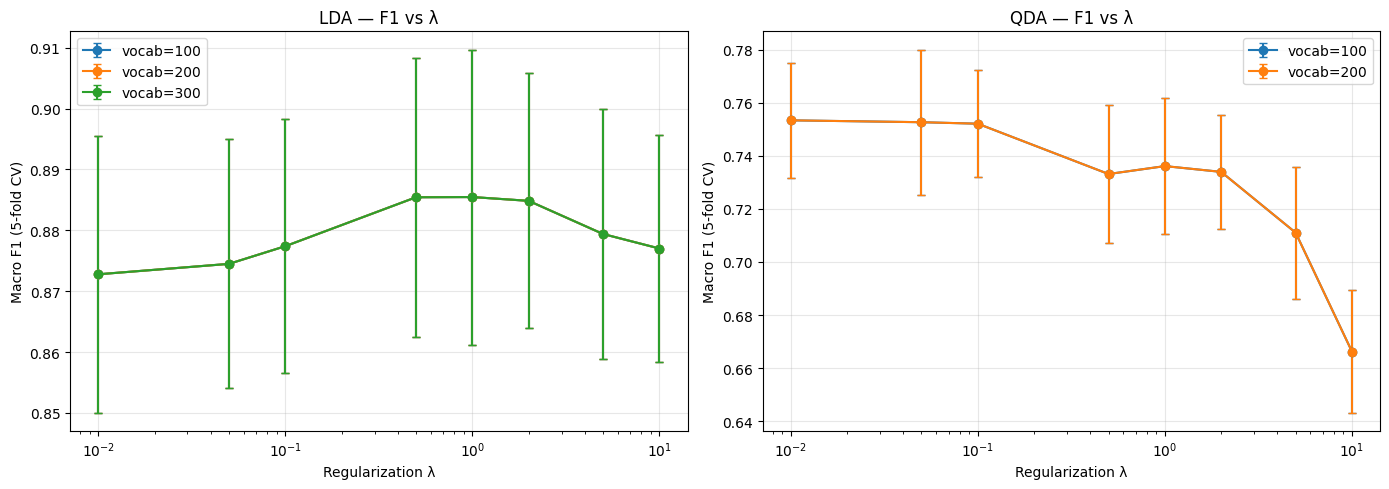

Saved: cv_lda_vs_qda.png


In [12]:
# ── Visualization: LDA vs QDA F1 scores ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_type, cv_df in [(axes[0], "LDA", cv_lda), (axes[1], "QDA", cv_qda)]:
    for feat in cv_df["max_features"].unique():
        sub = cv_df[cv_df["max_features"] == feat].sort_values("reg_lambda")
        ax.errorbar(
            sub["reg_lambda"], sub["mean_f1"], yerr=sub["std_f1"],
            marker="o", label=f"vocab={feat}", capsize=3,
        )
    ax.set_xscale("log")
    ax.set_xlabel("Regularization \u03bb")
    ax.set_ylabel("Macro F1 (5-fold CV)")
    ax.set_title(f"{model_type} — F1 vs \u03bb")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cv_lda_vs_qda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cv_lda_vs_qda.png")

## Step 9. Train final model and evaluate on held-out test set

We retrain the best model on the combined **train + validation** data (80% of respondents) and evaluate on the **test** set (20% of respondents) that has never been used for any decision.

In [13]:
# ── assemble train+val features ──
trainval_df = pd.concat([train_df, val_df]).reset_index(drop=True)

trainval_texts = concat_text_cols(trainval_df)
final_vocab = build_vocabulary(trainval_texts, max_features=BEST_FEATURES, min_df=3)
final_idf = compute_idf(trainval_texts, final_vocab)

X_trainval, final_meds, final_vocab, final_idf, final_fmeans, final_fstds = assemble_features(
    trainval_df, None, final_vocab, final_idf, None, None, fit=True
)
X_test, _, _, _, _, _ = assemble_features(
    test_df, final_meds, final_vocab, final_idf, final_fmeans, final_fstds, fit=False
)

print(f"Train+Val feature matrix: {X_trainval.shape}")
print(f"Test feature matrix:      {X_test.shape}")
print(f"Vocabulary size:          {len(final_vocab)}")
print(f"Best model type:          {'QDA' if BEST_QDA else 'LDA'}")
print(f"Best \u03bb:                   {BEST_LAMBDA}")

Train+Val feature matrix: (1347, 222)
Test feature matrix:      (339, 222)
Vocabulary size:          200
Best model type:          LDA
Best λ:                   1.0


In [14]:
# ── fit final model ──
final_model = fit_gda(X_trainval, trainval_df["label"].values, K, BEST_LAMBDA)
pred_fn = predict_qda if BEST_QDA else predict_lda

trainval_preds, trainval_probs = pred_fn(final_model, X_trainval)
test_preds, test_probs = pred_fn(final_model, X_test)

print("=" * 60)
print("TRAIN+VAL RESULTS")
print("=" * 60)
print(f"  Accuracy:  {accuracy(trainval_df['label'].values, trainval_preds):.4f}")
print(f"  Macro F1:  {f1_macro(trainval_df['label'].values, trainval_preds, K):.4f}")
print()
print("=" * 60)
print("TEST RESULTS")
print("=" * 60)
print(f"  Accuracy:  {accuracy(test_df['label'].values, test_preds):.4f}")
print(f"  Macro F1:  {f1_macro(test_df['label'].values, test_preds, K):.4f}")
print()

print("\nClassification Report (test):")
print_classification_report(test_df["label"].values, test_preds, CLASS_NAMES)

TRAIN+VAL RESULTS
  Accuracy:  0.9072
  Macro F1:  0.9076

TEST RESULTS
  Accuracy:  0.8879
  Macro F1:  0.8880


Classification Report (test):
                                  precision     recall   f1-score    support
---------------------------------------------------------------------------
       The Persistence of Memory     0.9231     0.8496     0.8848        113
                The Starry Night     0.8403     0.8850     0.8621        113
             The Water Lily Pond     0.9052     0.9292     0.9170        113
---------------------------------------------------------------------------
                        accuracy                           0.8879        339
                       macro avg     0.8895     0.8879     0.8880        339


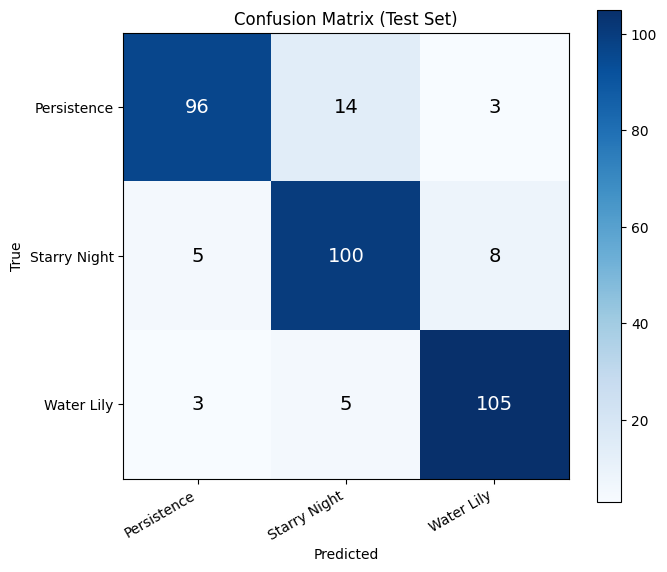

Saved: confusion_matrix.png


In [15]:
# ── confusion matrix heatmap ──
cm = confusion_matrix_manual(test_df["label"].values, test_preds, K)
short_names = ["Persistence", "Starry Night", "Water Lily"]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(K))
ax.set_yticks(range(K))
ax.set_xticklabels(short_names, rotation=30, ha="right")
ax.set_yticklabels(short_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Test Set)")

for i in range(K):
    for j in range(K):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=14)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

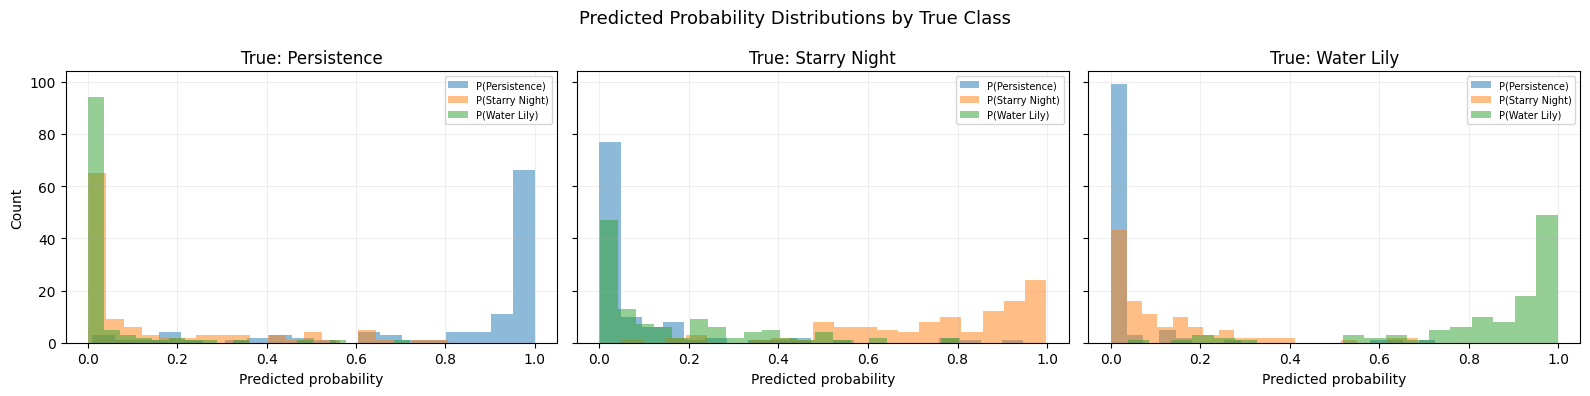

Saved: probability_distributions.png


In [16]:
# ── per-class probability distributions ──
fig, axes = plt.subplots(1, K, figsize=(16, 4), sharey=True)

for k, (ax, name) in enumerate(zip(axes, short_names)):
    mask = test_df["label"].values == k
    for j, cname in enumerate(short_names):
        ax.hist(test_probs[mask, j], bins=20, alpha=0.5, label=f"P({cname})")
    ax.set_title(f"True: {name}")
    ax.set_xlabel("Predicted probability")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Count")
plt.suptitle("Predicted Probability Distributions by True Class", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "probability_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: probability_distributions.png")

## Step 10. Error analysis

We examine misclassified samples to understand the model's weaknesses. Common error patterns can inform future feature engineering.

In [17]:
# ── identify misclassified test samples ──
y_true_test = test_df["label"].values
misclassified_mask = test_preds != y_true_test
n_errors = misclassified_mask.sum()

print(f"Total test samples:  {len(y_true_test)}")
print(f"Misclassified:       {n_errors} ({n_errors/len(y_true_test)*100:.1f}%)")
print()

# error breakdown
print("Error breakdown (True -> Predicted):")
error_pairs = Counter()
for t, p in zip(y_true_test[misclassified_mask], test_preds[misclassified_mask]):
    error_pairs[(CLASS_NAMES[t], CLASS_NAMES[p])] += 1

for (true_name, pred_name), count in error_pairs.most_common():
    print(f"  {true_name:>30s} -> {pred_name:<30s} : {count}")
print()

# confidence of misclassified samples
wrong_probs = test_probs[misclassified_mask]
wrong_confidence = wrong_probs.max(axis=1)
print(f"Misclassified confidence: mean={wrong_confidence.mean():.3f}, "
      f"median={np.median(wrong_confidence):.3f}, "
      f"max={wrong_confidence.max():.3f}")

correct_probs = test_probs[~misclassified_mask]
correct_confidence = correct_probs.max(axis=1)
print(f"Correct confidence:       mean={correct_confidence.mean():.3f}, "
      f"median={np.median(correct_confidence):.3f}")

Total test samples:  339
Misclassified:       38 (11.2%)

Error breakdown (True -> Predicted):
       The Persistence of Memory -> The Starry Night               : 14
                The Starry Night -> The Water Lily Pond            : 8
                The Starry Night -> The Persistence of Memory      : 5
             The Water Lily Pond -> The Starry Night               : 5
       The Persistence of Memory -> The Water Lily Pond            : 3
             The Water Lily Pond -> The Persistence of Memory      : 3

Misclassified confidence: mean=0.628, median=0.614, max=0.947
Correct confidence:       mean=0.878, median=0.941
